In this notebook we'll quantify the differences between the raw text data of the paraphrases and the prompt generations.

In [1]:
import json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

/home/jdias/miniconda3/envs/vf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading data

Previous auxiliar functions

In [9]:
def choose_device(device):
    if device==0:
        return 'cuda:0'
    elif device==1:
        return 'cuda:1'
    elif device ==-1:
        return 'cpu'
    else:
        raise Exception('Return 0 or 1 for GPUs or -1 for CPU')

def load_device(cuda_id):
    cuda = choose_device(cuda_id)
    device = torch.device(cuda if torch.cuda.is_available() else "cpu")
    return device

def load_AutoModel(model_id,cuda_id):
    
    tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side = "left") 
    tokenizer.pad_token_id = tokenizer.eos_token_id #required in llama because no padding token is defined
    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16)
    terminators = [
        tokenizer.eos_token_id,
        tokenizer.convert_tokens_to_ids("<|eot_id|>")
    ]
    device = load_device(cuda_id)
    model = model.to(device)

    return tokenizer, model, device, terminators

def load_prompts(prompt_type, prompt_topic):
    #load prompt from .txt
    if prompt_type == 'completion':
        with open('../prompts-comp/'+prompt_topic+'.txt') as file:
            prompt = file.read()
    elif prompt_type == 'generation':
        with open('../prompts-gen/'+prompt_topic+'.txt') as file:
            prompt = file.read()
        prompt = json.loads(prompt, strict=False)
    return prompt

def prepare_llama_prompt(tokenizer, prompt, device):
    text = tokenizer.apply_chat_template(prompt, add_generation_prompt=True, tokenize=False) 
    inputs = tokenizer(text, padding="longest", return_tensors="pt") #transform into pt tensors
    inputs = {key: val.to(device) for key, val in inputs.items()} #move inputs into cuda
    return inputs

def llama_gen(model, inputs, tokenizer, terminators, num_generations):
    generations = model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=terminators,
        num_return_sequences=num_generations  
    )

    return generations

def load_prompt_and_gen(prompt_type, prompt_topic, model, tokenizer, terminators, device):
    prompt = load_prompts(prompt_type, prompt_topic)
    model_inputs = prepare_llama_prompt(tokenizer, prompt, device)
    gen_ids = llama_gen(model, model_inputs, tokenizer, terminators, num_generations=100)

    return gen_ids, model_inputs

### Load prompt-based generations and decode them

Auxiliar function for this notebook

In [11]:
def load_tokens_and_decode(gen_ids, model_inputs, tokenizer):
    tensor_size_prompt = model_inputs['input_ids'].shape[1]
    return tokenizer.batch_decode(gen_ids[:,tensor_size_prompt:],skip_special_tokens=True)

In [4]:
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"
tokenizer, model, device, terminators = load_AutoModel(model_id, cuda_id=0)

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 135.88it/s]


In [5]:
viktor_list = load_tokens_and_decode(prompt_type="generation",prompt_topic="viktor",tokenizer=tokenizer, device=device)
prague_list = load_tokens_and_decode(prompt_type="generation",prompt_topic="prague",tokenizer=tokenizer, device=device)
sciencefic_list = load_tokens_and_decode(prompt_type="generation",prompt_topic="sciencefic",tokenizer=tokenizer, device=device)

In [13]:
viktor_ids, viktor_inputs = load_prompt_and_gen(prompt_type = "generation", prompt_topic="viktor", model=model, tokenizer=tokenizer, terminators=terminators, device=device)
prague_ids, prague_inputs = load_prompt_and_gen(prompt_type = "generation", prompt_topic="prague", model=model, tokenizer=tokenizer, terminators=terminators, device=device)
sciencefic_ids, sciencefic_inputs = load_prompt_and_gen(prompt_type = "generation", prompt_topic="sciencefic", model=model, tokenizer=tokenizer, terminators=terminators, device=device)

In [ ]:
viktor_list = load_tokens_and_decode(gen_ids=viktor_ids, model_inputs=viktor_inputs, tokenizer=tokenizer)
prague_list  = load_tokens_and_decode(gen_ids=prague_ids, model_inputs=prague_inputs, tokenizer=tokenizer)
sciencefic_list = load_tokens_and_decode(gen_ids=sciencefic_ids, model_inputs=sciencefic_inputs, tokenizer=tokenizer)

### Load paraphrased generations

In [17]:
def remove_clause_numbers(story: str) -> str:
    #d+ - one or more digits, \. - dot, \s* - newlines and spaces
    cleaned = re.sub(r"\d+\.\s*", "", story) 
    #remove additional spaces
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [18]:
dir_path = "../rephrasings"

first_stories = {}
second_stories = {}

for i in range(1, 4):
    first_file_path = f"story{i}.json"
    second_file_path = f"{i}_high_temp_costly.json"

    first_path = os.path.join(dir_path,first_file_path)
    second_path = os.path.join(dir_path,second_file_path)

    with open(first_path, "r", encoding="utf-8") as f:
        first_stories[i] = json.load(f)
    with open(second_path, "r", encoding="utf-8") as f:
        second_stories[i] = json.load(f)

In [19]:
para1_list_1 = [remove_clause_numbers(story) for story in first_stories[1]]
para1_list_2 = [remove_clause_numbers(story) for story in first_stories[2]]
para1_list_3 = [remove_clause_numbers(story) for story in first_stories[3]]

para2_list_1 = [remove_clause_numbers(story) for story in second_stories[1]]
para2_list_2 = [remove_clause_numbers(story) for story in second_stories[2]]
para2_list_3 = [remove_clause_numbers(story) for story in second_stories[3]]

In [2]:
from pathlib import Path
import json
import torch

def load_json_lists_under(folder: Path) -> dict:
    """
    Recursively load all *.json files under `folder`.
    Returns a dict: { "relative/path/stem": [list_of_strings], ... }
    """
    data = {}
    for p in folder.rglob("*.json"):
        try:
            with open(p, "r", encoding="utf-8") as f:
                contents = json.load(f)
            if isinstance(contents, list) and all(isinstance(x, str) for x in contents):
                key = str(p.relative_to(folder).with_suffix(""))  # relative path without .json
                data[key] = contents
        except Exception as e:
            print(f"Skipping {p}: {e}")
    return data


root = Path("../model-comparison/data/")

for folder in root.iterdir():
    if folder.is_dir():
        var_name = f"{folder.name}"
        globals()[var_name] = load_json_lists_under(folder)
        print(f"Loaded {len(globals()[var_name])} JSON files into `{var_name}`")

Loaded 9 JSON files into `shuffled_words`
Loaded 9 JSON files into `shuffled_sentences`
Loaded 9 JSON files into `shuffled_tokens`
Loaded 9 JSON files into `clean`


In [4]:
viktor_list = clean["viktor"]
prague_list  = clean["prague"]
sciencefic_list = clean["sciencefic"]

para1_list_1 = clean["gpt4_para1"]
para1_list_2 = clean["gpt4_para2"]
para1_list_3 = clean["gpt4_para3"]

para2_list_1 = clean["gpt5_para1"]
para2_list_2 = clean["gpt5_para2"]
para2_list_3 = clean["gpt5_para3"]

## Sentence length tests

In [30]:
viktor_len = [len(story.split()) for story in viktor_list]
prague_len = [len(story.split()) for story in prague_list]
sciencefic_len = [len(story.split()) for story in sciencefic_list]

para1_list_1_len = [len(story.split()) for story in para1_list_1]
para1_list_2_len = [len(story.split()) for story in para1_list_2]
para1_list_3_len = [len(story.split()) for story in para1_list_3]

para2_list_1_len = [len(story.split()) for story in para2_list_1]
para2_list_2_len = [len(story.split()) for story in para2_list_2]
para2_list_3_len = [len(story.split()) for story in para2_list_3]

batch_lengths = [viktor_len,prague_len,sciencefic_len,
                 para1_list_1_len, para1_list_2_len,para1_list_3_len,
                 para2_list_1_len,para2_list_2_len,para2_list_3_len]


labels = [
    "Viktor", "Prague", "Science Fiction",
    "GPT4_Para1", "GPT4_Para2", "GPT4_Para3",
    "GPT5_Para1", "GPT5_Para2", "GPT5_Para3"
]

# colors = [
#     "#1f77b4", "#ff7f0e", "#2ca02c",
#     "#d62728", "#9467bd", "#8c564b",
#     "#e377c2", "#7f7f7f", "#bcbd22"
# ]

colors = sns.color_palette("pastel", len(labels))

#### Which group of stories tend to be longer?

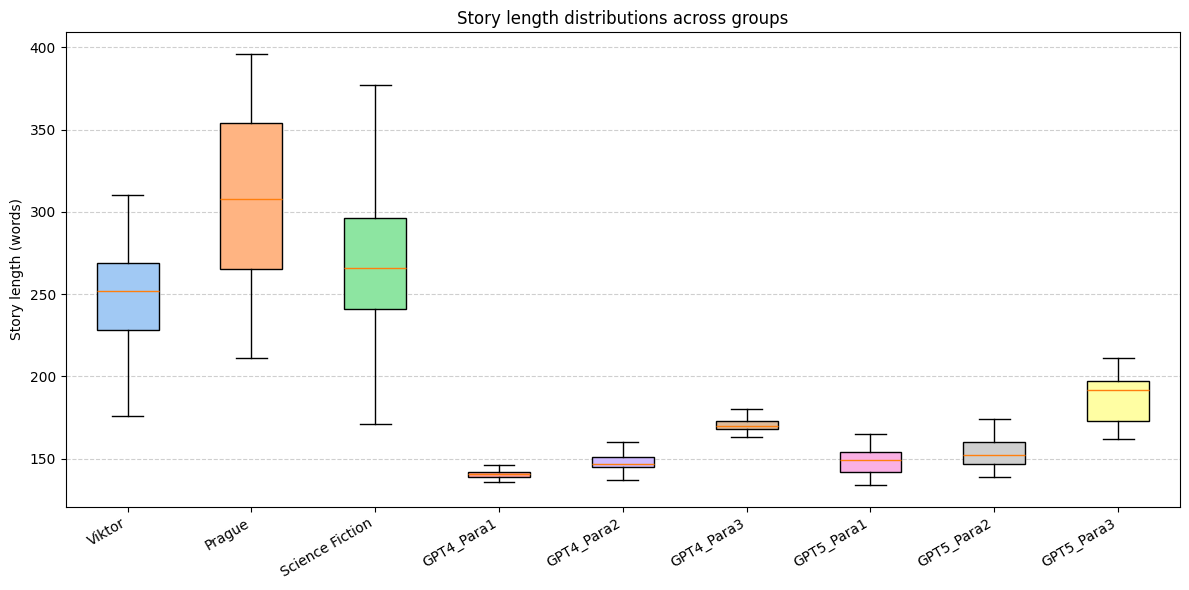

In [9]:
#boxplot
plt.figure(figsize=(12, 6))
box = plt.boxplot(batch_lengths, patch_artist=True, tick_labels=labels, showfliers=False)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel("Story length (words)")
plt.title("Story length distributions across groups")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


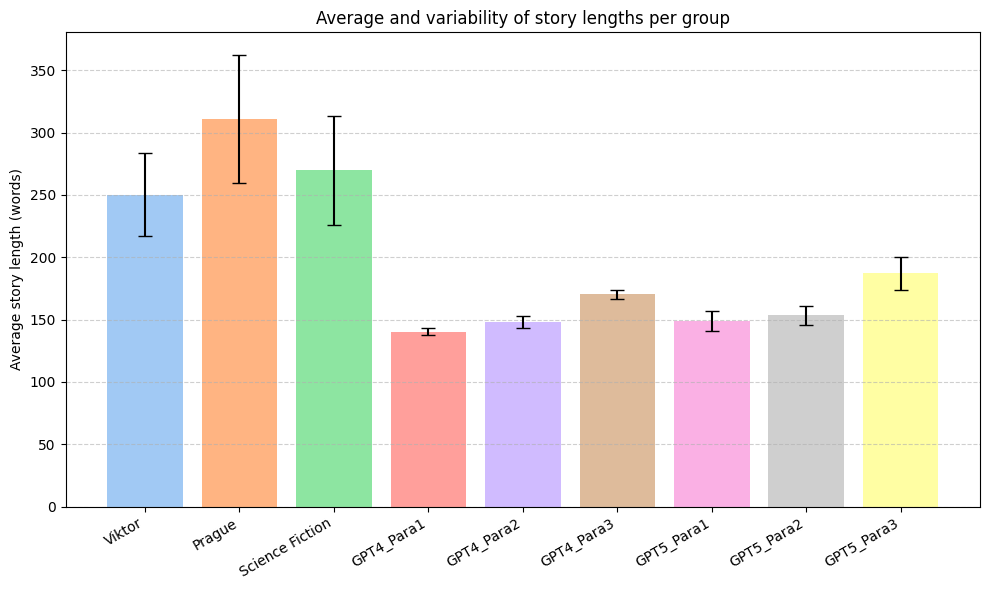

In [10]:
means = [np.mean(lens) for lens in batch_lengths]
stds = [np.std(lens) for lens in batch_lengths]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, means, yerr=stds, color=colors, capsize=5)
plt.ylabel("Average story length (words)")
plt.title("Average and variability of story lengths per group")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#### Checking the spread per batch

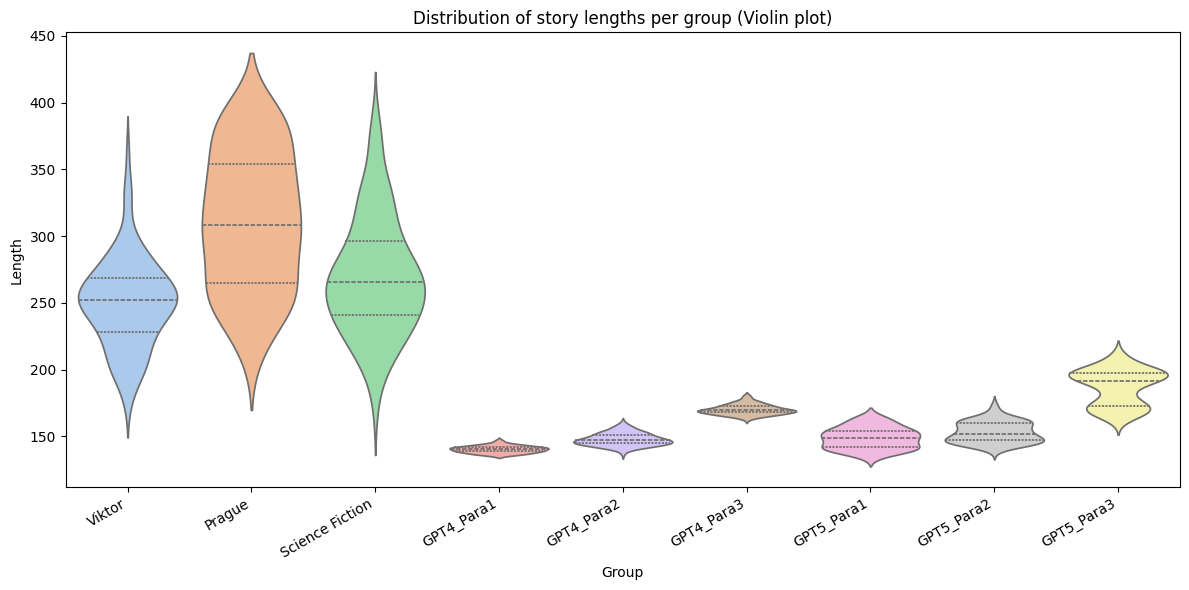

In [11]:
#violin plot - density view
data = []
for label, lens in zip(labels, batch_lengths):
    for l in lens:
        data.append({"Group": label, "Length": l})
df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x="Group",
    y="Length",
    hue="Group",          # explicitly set hue
    palette=colors,       # your color palette
    inner="quartile",
    legend=False          # disables redundant legend
)
plt.title("Distribution of story lengths per group (Violin plot)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


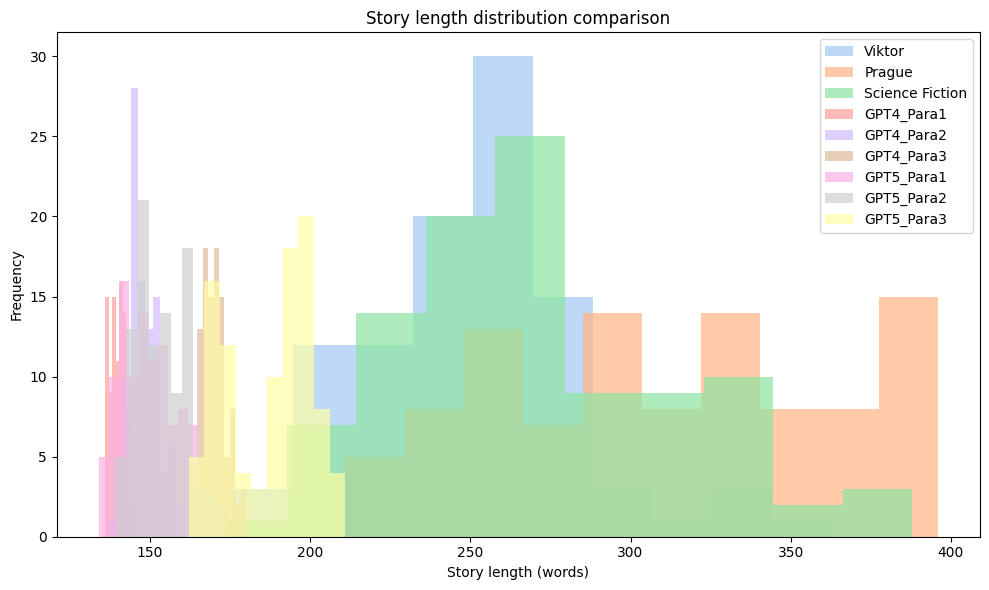

In [12]:
plt.figure(figsize=(10, 6))
bins = 10  # Adjust granularity

for lens, label, color in zip(batch_lengths, labels, colors):
    plt.hist(lens, bins=bins, alpha=0.7, label=label, color=color)

plt.xlabel("Story length (words)")
plt.ylabel("Frequency")
plt.title("Story length distribution comparison")
plt.legend()
plt.tight_layout()
plt.show()


## Different words per story

In [13]:
def count_unique_words(text):
    #extract only word characters and use lowercase text
    words = re.findall(r'\b\w+\b', text.lower()) 
    return len(set(words))

viktor_unique = [count_unique_words(story) for story in viktor_list]
prague_unique = [count_unique_words(story) for story in prague_list]
sciencefic_unique = [count_unique_words(story) for story in sciencefic_list]

para1_list_1_unique = [count_unique_words(story) for story in para1_list_1]
para1_list_2_unique = [count_unique_words(story) for story in para1_list_2]
para1_list_3_unique = [count_unique_words(story) for story in para1_list_3]

para2_list_1_unique = [count_unique_words(story) for story in para2_list_1]
para2_list_2_unique = [count_unique_words(story) for story in para2_list_2]
para2_list_3_unique = [count_unique_words(story) for story in para2_list_3]

batch_unique_counts = [
    viktor_unique, prague_unique, sciencefic_unique,
    para1_list_1_unique, para1_list_2_unique, para1_list_3_unique,
    para2_list_1_unique, para2_list_2_unique, para2_list_3_unique
]

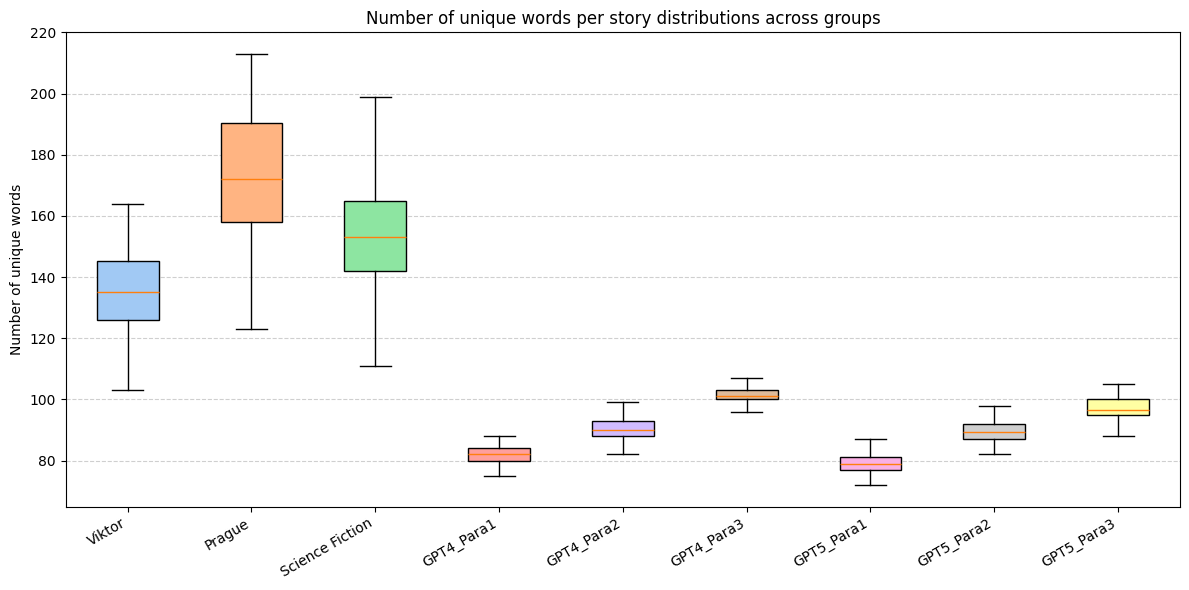

In [14]:
#boxplot
plt.figure(figsize=(12, 6))
box = plt.boxplot(batch_unique_counts, patch_artist=True, tick_labels=labels, showfliers=False)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel("Number of unique words")
plt.title("Number of unique words per story distributions across groups")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

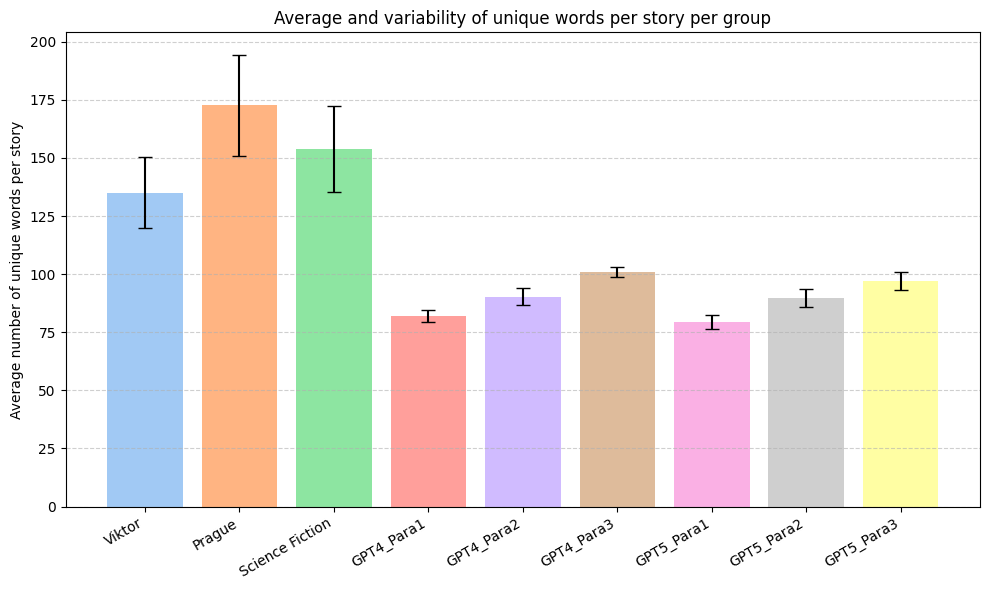

In [15]:
means = [np.mean(lens) for lens in batch_unique_counts]
stds = [np.std(lens) for lens in batch_unique_counts]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, means, yerr=stds, color=colors, capsize=5)
plt.ylabel("Average number of unique words per story")
plt.title("Average and variability of unique words per story per group")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

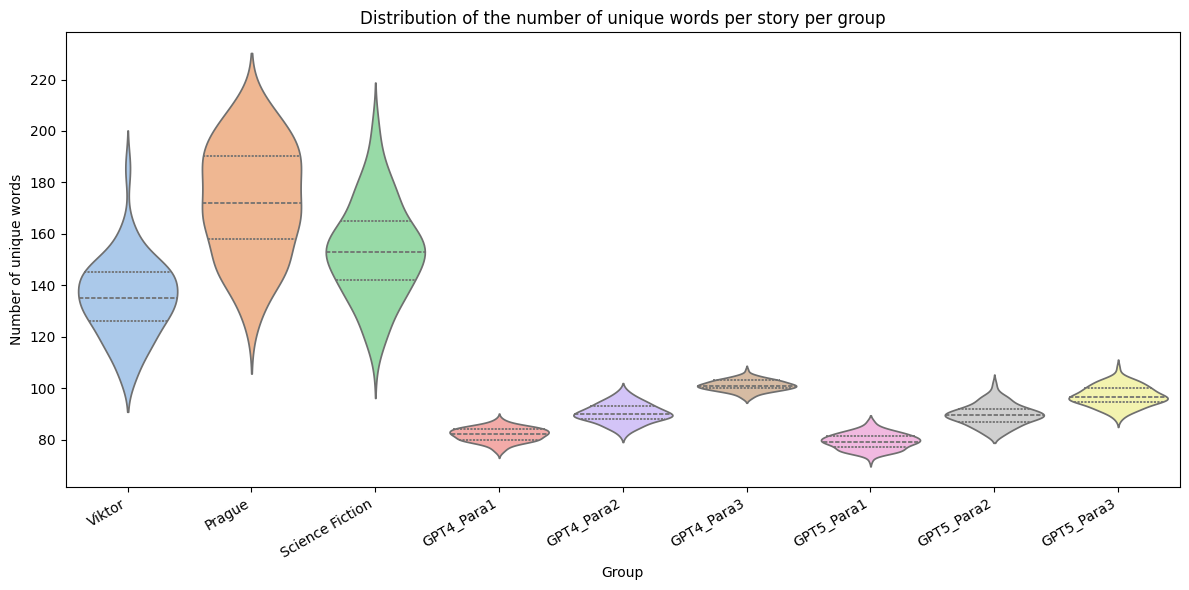

In [16]:
#violin plot - density view
data = []
for label, lens in zip(labels, batch_unique_counts):
    for l in lens:
        data.append({"Group": label, "Number of unique words": l})
df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x="Group",
    y="Number of unique words",
    hue="Group",          # explicitly set hue
    palette=colors,       # your color palette
    inner="quartile",
    legend=False          # disables redundant legend
)
plt.title("Distribution of the number of unique words per story per group")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


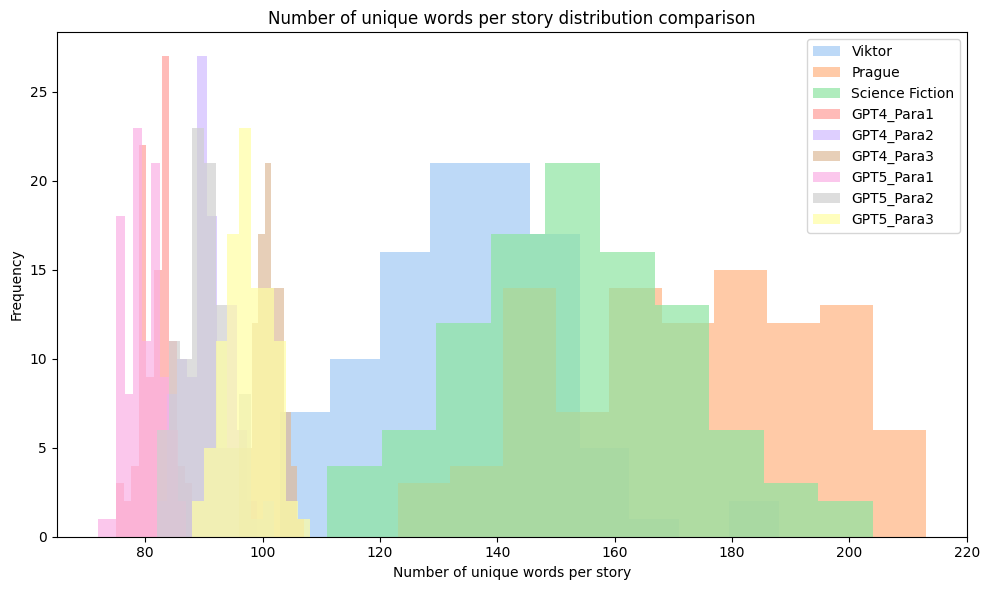

In [17]:
plt.figure(figsize=(10, 6))
bins = 10  # Adjust granularity

for lens, label, color in zip(batch_unique_counts, labels, colors):
    plt.hist(lens, bins=bins, alpha=0.7, label=label, color=color)

plt.xlabel("Number of unique words per story")
plt.ylabel("Frequency")
plt.title("Number of unique words per story distribution comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Lexical diversity for each story

In [18]:
def lexical_diversity(text):
    words = re.findall(r'\b\w+\b', text.lower())
    if not words:
        return 0
    return len(set(words)) / len(words)

viktor_diversity = [lexical_diversity(story) for story in viktor_list]
prague_diversity = [lexical_diversity(story) for story in prague_list]
sciencefic_diversity = [lexical_diversity(story) for story in sciencefic_list]

para1_list_1_diversity = [lexical_diversity(story) for story in para1_list_1]
para1_list_2_diversity = [lexical_diversity(story) for story in para1_list_2]
para1_list_3_diversity = [lexical_diversity(story) for story in para1_list_3]

para2_list_1_diversity = [lexical_diversity(story) for story in para2_list_1]
para2_list_2_diversity = [lexical_diversity(story) for story in para2_list_2]
para2_list_3_diversity = [lexical_diversity(story) for story in para2_list_3]

batch_diversity_counts = [
    viktor_diversity, prague_diversity, sciencefic_diversity,
    para1_list_1_diversity, para1_list_2_diversity, para1_list_3_diversity,
    para2_list_1_diversity, para2_list_2_diversity, para2_list_3_diversity
]

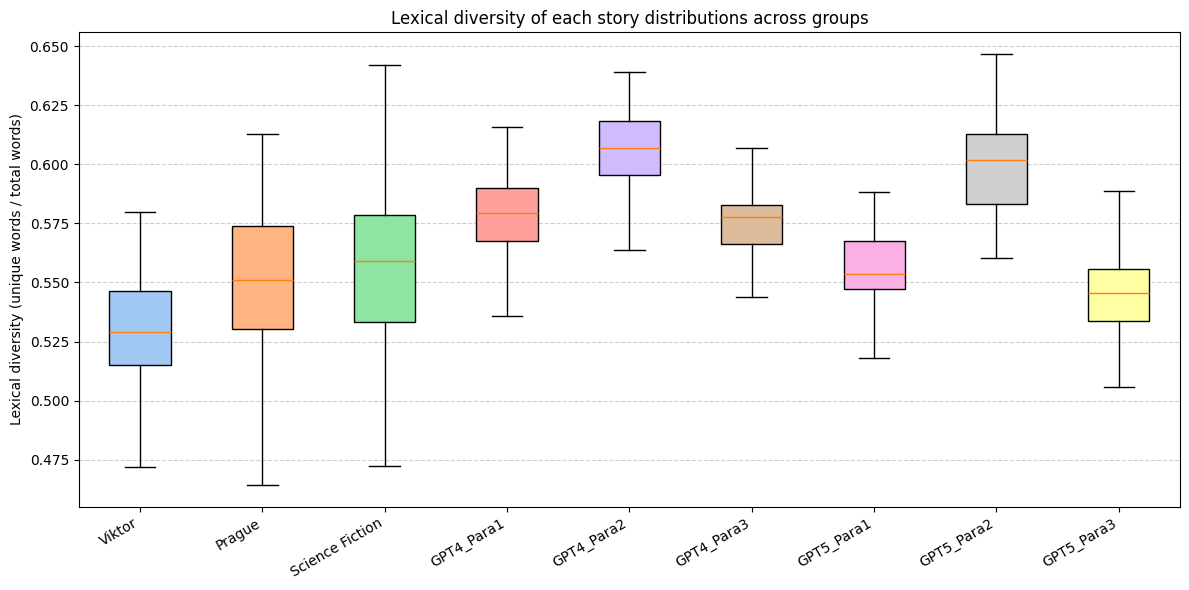

In [19]:
#boxplot
plt.figure(figsize=(12, 6))
box = plt.boxplot(batch_diversity_counts, patch_artist=True, tick_labels=labels, showfliers=False)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel("Lexical diversity (unique words / total words)")
plt.title("Lexical diversity of each story distributions across groups")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

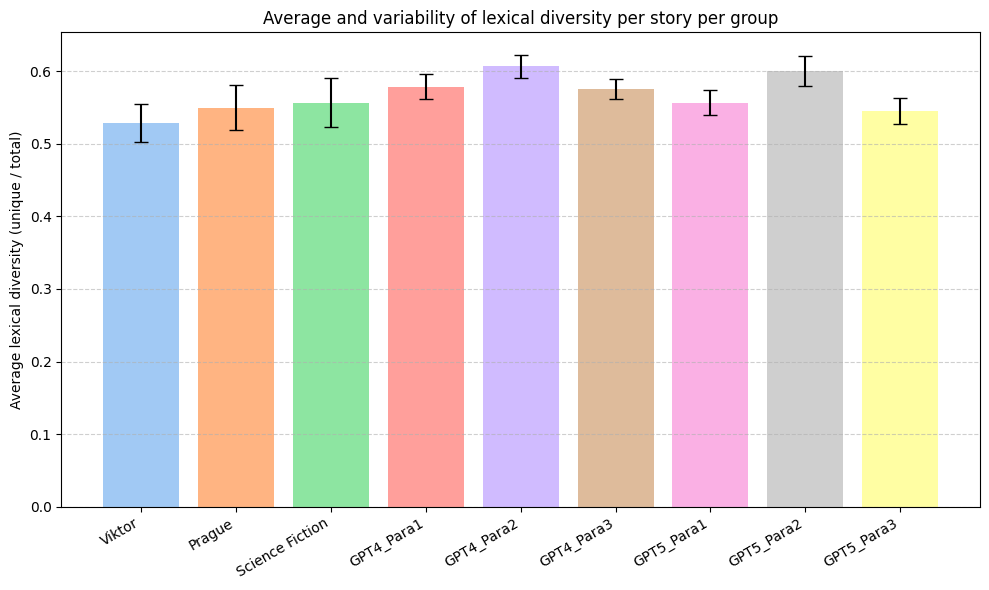

In [20]:
means = [np.mean(lens) for lens in batch_diversity_counts]
stds = [np.std(lens) for lens in batch_diversity_counts]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, means, yerr=stds, color=colors, capsize=5)
plt.ylabel("Average lexical diversity (unique / total)")
plt.title("Average and variability of lexical diversity per story per group")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

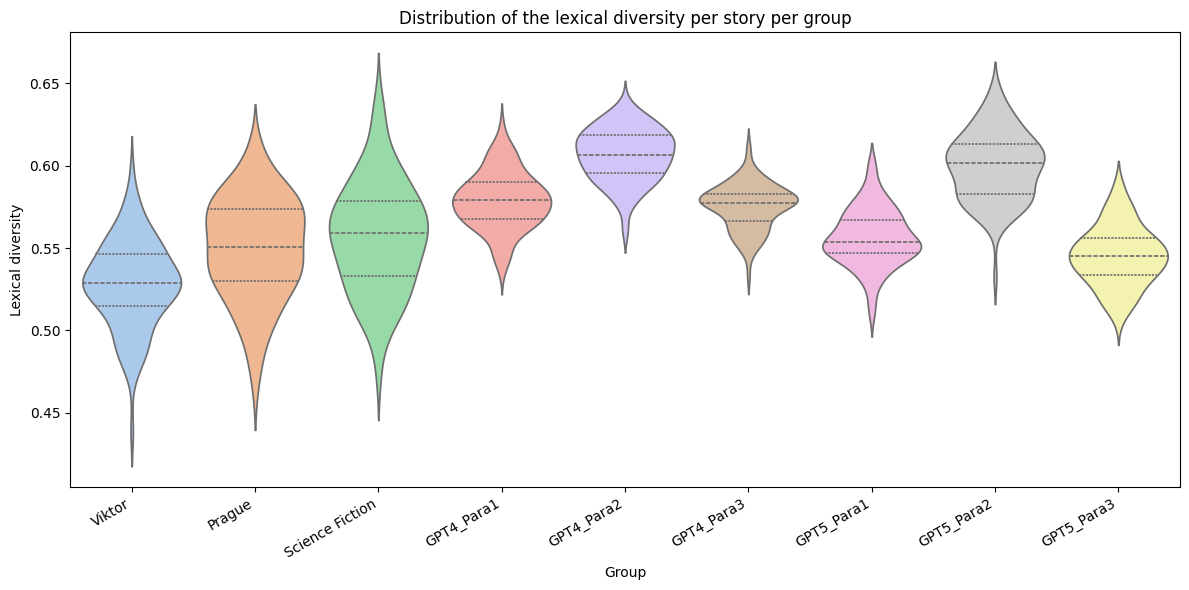

In [21]:
#violin plot - density view
data = []
for label, lens in zip(labels, batch_diversity_counts):
    for l in lens:
        data.append({"Group": label, "Lexical diversity": l})
df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x="Group",
    y="Lexical diversity",
    hue="Group",          # explicitly set hue
    palette=colors,       # your color palette
    inner="quartile",
    legend=False          # disables redundant legend
)
plt.title("Distribution of the lexical diversity per story per group")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

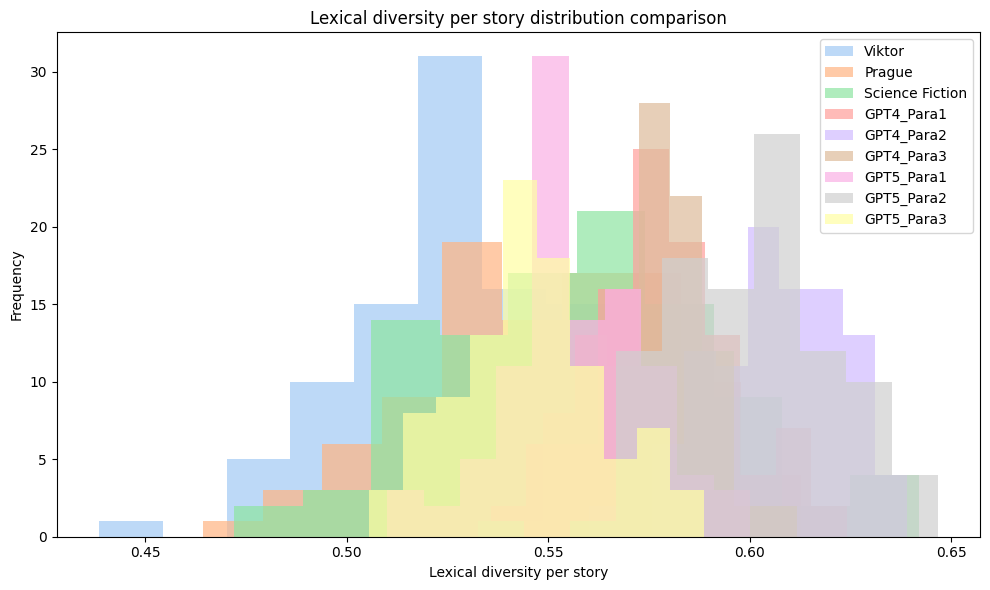

In [22]:
plt.figure(figsize=(10, 6))
bins = 10  # Adjust granularity

for lens, label, color in zip(batch_diversity_counts, labels, colors):
    plt.hist(lens, bins=bins, alpha=0.7, label=label, color=color)

plt.xlabel("Lexical diversity per story")
plt.ylabel("Frequency")
plt.title("Lexical diversity per story distribution comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Lexical diversity between story generations

In [23]:
def batch_lexical_diversity(stories):
    full_text = " ".join(stories) #combine all stories into one text

    #extract words
    words = re.findall(r'\b\w+\b', full_text.lower())
    total_words = len(words)
    unique_words = len(set(words))
    ratio = unique_words / total_words if total_words > 0 else 0
    return unique_words, ratio

batch_lists = [
    viktor_list, prague_list, sciencefic_list,
    para1_list_1, para1_list_2, para1_list_3,
    para2_list_1, para2_list_2, para2_list_3
]

batch_labels = [
    "Viktor", "Prague", "Science Fiction",
    "Para1 List 1", "Para1 List 2", "Para1 List 3",
    "Para2 List 1", "Para2 List 2", "Para2 List 3"
]

batch_unique_counts_total = []
batch_diversity_ratios_total = []

for batch in batch_lists:
    unique, ratio = batch_lexical_diversity(batch)
    batch_unique_counts_total.append(unique)
    batch_diversity_ratios_total.append(ratio)

for label, u, r in zip(batch_labels, batch_unique_counts_total, batch_diversity_ratios_total):
    print(f"{label}: {u} unique words, lexical diversity = {r:.3f}")


Viktor: 1133 unique words, lexical diversity = 0.044
Prague: 2042 unique words, lexical diversity = 0.065
Science Fiction: 2243 unique words, lexical diversity = 0.081
Para1 List 1: 203 unique words, lexical diversity = 0.014
Para1 List 2: 330 unique words, lexical diversity = 0.022
Para1 List 3: 282 unique words, lexical diversity = 0.016
Para2 List 1: 194 unique words, lexical diversity = 0.014
Para2 List 2: 279 unique words, lexical diversity = 0.019
Para2 List 3: 236 unique words, lexical diversity = 0.013


## Mean Dependency Distance (MDD)

In [24]:
import spacy

nlp = spacy.load("en_core_web_sm")

def calculate_story_mdd(story_text):
    """Calculate MDD for an entire story"""
    doc = nlp(story_text)
    
    total_distance = 0
    total_dependencies = 0
    
    for sent in doc.sents:
        for token in sent:
            if token.head != token:  # exclude root
                distance = abs(token.i - token.head.i)
                total_distance += distance
                total_dependencies += 1
    
    return total_distance / total_dependencies if total_dependencies > 0 else 0

def calculate_list_average_mdd(story_list):
    """Calculate average MDD for a list of stories"""
    mdds = []
    for story in story_list:
        mdd = calculate_story_mdd(story)
        mdds.append(mdd)
    
    average = sum(mdds) / len(mdds) if mdds else 0
    return average, mdds

batch_lists = [
    viktor_list, prague_list, sciencefic_list,
    para1_list_1, para1_list_2, para1_list_3,
    para2_list_1, para2_list_2, para2_list_3
]

list_names = [
    "viktor_list", "prague_list", "sciencefic_list",
    "para1_list_1", "para1_list_2", "para1_list_3",
    "para2_list_1", "para2_list_2", "para2_list_3"
]

#calculate MDD for each list
results = {}
for name, story_list in zip(list_names, batch_lists):
    avg_mdd, individual_mdds = calculate_list_average_mdd(story_list)
    results[name] = {
        'average_mdd': avg_mdd,
        'individual_mdds': individual_mdds,
        'num_stories': len(story_list)
    }
    print(f"{name}:")
    print(f"  Average MDD: {avg_mdd:.4f}")
    print(f"  MDD range: {min(individual_mdds):.4f} - {max(individual_mdds):.4f}")
    print()

#calculate overall average across all lists
all_averages = [results[name]['average_mdd'] for name in list_names]
overall_average = sum(all_averages) / len(all_averages)
print(f"Overall average MDD across all lists: {overall_average:.4f}")

summary = {
    'by_list': results,
    'overall_average': overall_average
}

viktor_list:
  Average MDD: 2.9322
  MDD range: 2.6715 - 3.2393

prague_list:
  Average MDD: 2.8622
  MDD range: 2.5706 - 3.3232

sciencefic_list:
  Average MDD: 2.8652
  MDD range: 2.4751 - 3.2918

para1_list_1:
  Average MDD: 2.9722
  MDD range: 2.8089 - 3.1491

para1_list_2:
  Average MDD: 2.4864
  MDD range: 2.3557 - 2.6543

para1_list_3:
  Average MDD: 3.0045
  MDD range: 2.6850 - 3.1168

para2_list_1:
  Average MDD: 2.8897
  MDD range: 2.5588 - 3.0789

para2_list_2:
  Average MDD: 2.4623
  MDD range: 1.9728 - 2.6405

para2_list_3:
  Average MDD: 2.7869
  MDD range: 2.4839 - 3.0722

Overall average MDD across all lists: 2.8068


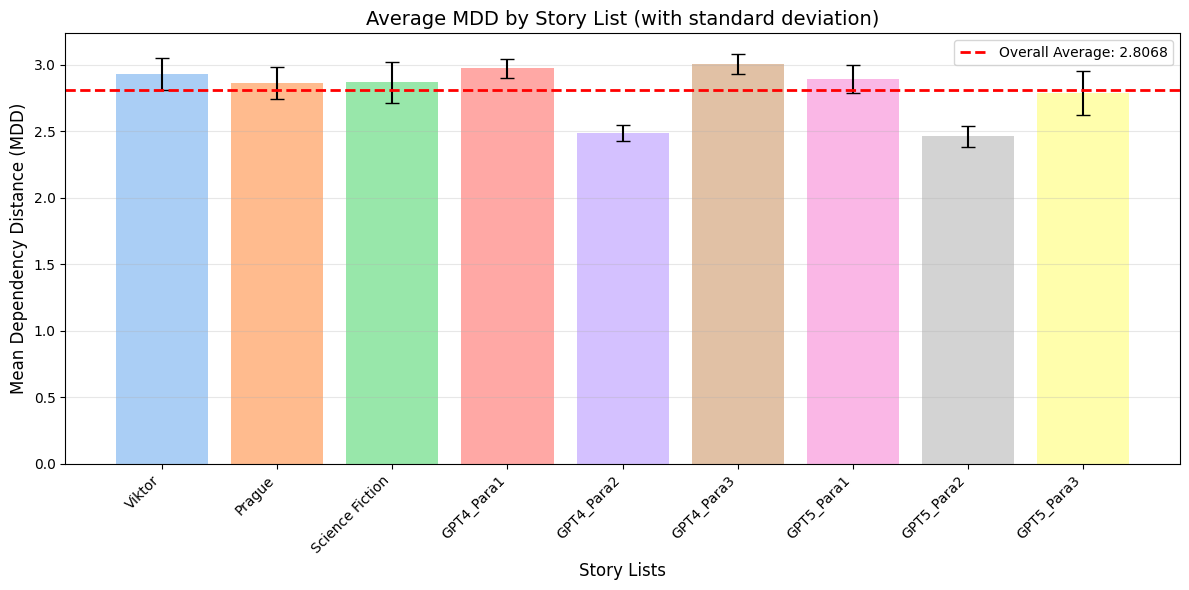

In [32]:
averages = [results[name]['average_mdd'] for name in list_names]
std_devs = [np.std(results[name]['individual_mdds']) for name in list_names]
#labels = list_names
colors = sns.color_palette("pastel", len(labels))

#plot 1: Average MDD by list with error bars
fig1, ax1 = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(labels))
bars = ax1.bar(x_pos, averages, yerr=std_devs, capsize=5, alpha=0.9, color=colors)

ax1.set_xlabel('Story Lists', fontsize=12, fontweight='normal')
ax1.set_ylabel('Mean Dependency Distance (MDD)', fontsize=12, fontweight='normal')
ax1.set_title('Average MDD by Story List (with standard deviation)', fontsize=14, fontweight='normal')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.axhline(y=overall_average, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Average: {overall_average:.4f}')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

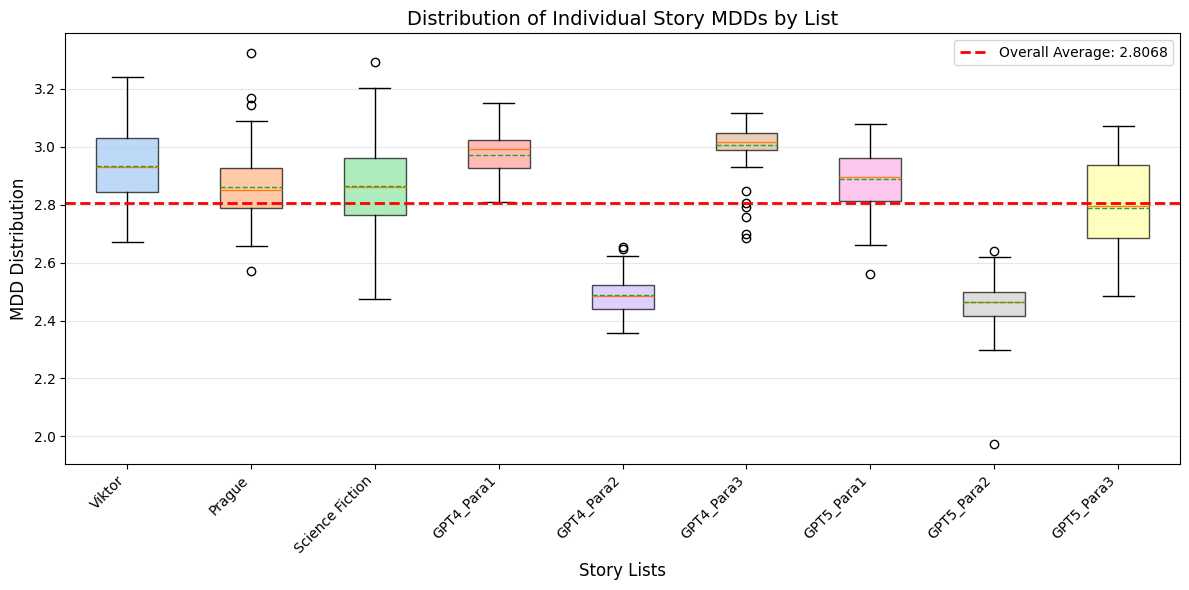

In [33]:
#plot 2: Distribution of individual MDDs across all lists

fig2, ax2 = plt.subplots(figsize=(12, 6))

data_to_plot = [results[name]['individual_mdds'] for name in list_names]

bp = ax2.boxplot(data_to_plot, tick_labels=labels, patch_artist=True, 
                 showmeans=True, meanline=True)

# Color the boxplots
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Story Lists', fontsize=12, fontweight='normal')
ax2.set_ylabel('MDD Distribution', fontsize=12, fontweight='normal')
ax2.set_title('Distribution of Individual Story MDDs by List', fontsize=14, fontweight='normal')
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.axhline(y=overall_average, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Average: {overall_average:.4f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Mean Dependency Distance (MDD) Analysis - Claude

**Key Findings:**

- **Overall Average MDD:** 2.82
- **Most Complex:** para1_list_1 (MDD ~3.0), para1_list_3, para2_list_1
- **Least Complex:** para2_list_2 (MDD ~2.45), para1_list_2 (MDD ~2.48)

**Two Distinct Groups:**
- **Above average complexity:** viktor_list, prague_list, sciencefic_list, para1_list_1, para1_list_3, para2_list_1, para2_list_3
- **Below average complexity:** para1_list_2, para2_list_2

**Variability:**
- viktor_list and prague_list show high variability with multiple outliers
- para lists show more consistent syntactic complexity (tighter distributions)
- para2_list_2 has one notable outlier at MDD ~1.98

**Interpretation:** Higher MDD indicates more complex syntactic structures with longer-distance grammatical relationships, suggesting more elaborate writing styles and greater cognitive processing demands for readers.